# Offline RL on CartPole-v1 (Discrete Models + Metrics)

Loads the Hugging Face dataset `NathanGavenski/CartPole-v1`, trains discrete offline RL baselines (BC, DQN, Double DQN, Dueling DQN, CQL), and reports return/length/success metrics.

In [4]:
%pip install -q datasets gymnasium torch numpy matplotlib
import sys
import os
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from datasets import load_dataset
from matplotlib import pyplot as plt

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Gymnasium:", gym.__version__)

Note: you may need to restart the kernel to use updated packages.
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
Gymnasium: 1.2.0


In [5]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

dataset_id = "NathanGavenski/CartPole-v1"
dataset_split = "train"
env_id = "CartPole-v1"

use_subset = True
subset_size = 50_000
enable_hf_transfer = True

num_updates = 20_000
batch_size = 256
eval_episodes = 20
max_episode_steps = 500
grad_clip = 5.0

lr_bc = 3e-4
lr_q = 3e-4
gamma = 0.99
target_update_freq = 250
tau = 0.01
cql_alpha = 1.0

Device: cuda


In [6]:
def _pick_column(column_names, candidates):
    for name in candidates:
        if name in column_names:
            return name
    return None

print("Loading dataset...")
if enable_hf_transfer:
    os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

# Optional: set HF_TOKEN in Kaggle secrets for faster authenticated downloads.
hf_token = os.environ.get("HF_TOKEN", None)

# Streaming-first path avoids waiting for full dataset file download.
stream_ds = load_dataset(
    dataset_id,
    split=dataset_split,
    streaming=True,
    token=hf_token,
 )

first_row = next(iter(stream_ds.take(1)))
columns = list(first_row.keys())
print("Columns:", columns)

obs_col = _pick_column(columns, ["observations", "obs", "state", "states"] )
act_col = _pick_column(columns, ["actions", "action", "acts"])
rew_col = _pick_column(columns, ["rewards", "reward"] )
next_obs_col = _pick_column(columns, ["next_observations", "next_obs", "next_state", "next_states"] )
done_col = _pick_column(columns, ["dones", "done", "terminals", "terminal", "terminated"])
trunc_col = _pick_column(columns, ["truncations", "truncated", "timeouts"])

if obs_col is None or act_col is None or rew_col is None:
    raise RuntimeError("Required columns not found in dataset")

env = gym.make(env_id)
num_actions = env.action_space.n

limit = subset_size if use_subset else 200000
obs_list, actions_list, rewards_list = [], [], []
next_obs_list, dones_list = [], []

for row in stream_ds.take(limit):
    o = np.asarray(row[obs_col], dtype=np.float32).reshape(-1)
    a = int(row[act_col])
    r = float(row[rew_col])

    if next_obs_col is not None:
        no = np.asarray(row[next_obs_col], dtype=np.float32).reshape(-1)
    else:
        no = o

    d = float(row[done_col]) if done_col is not None else 0.0
    if trunc_col is not None:
        d = float(np.clip(d + float(row[trunc_col]), 0.0, 1.0))

    obs_list.append(o)
    actions_list.append(a)
    rewards_list.append(r)
    next_obs_list.append(no)
    dones_list.append(d)

obs = np.asarray(obs_list, dtype=np.float32)
actions = np.asarray(actions_list, dtype=np.int64).reshape(-1)
rewards = np.asarray(rewards_list, dtype=np.float32).reshape(-1)
next_obs = np.asarray(next_obs_list, dtype=np.float32)
dones = np.asarray(dones_list, dtype=np.float32).reshape(-1)

print("Dataset loaded:", dataset_id, "split:", dataset_split, "streaming")
print("Transitions:", len(obs))
print("Obs dim:", obs.shape[1], "Num actions:", num_actions)
print("Reward stats:", rewards.min(), rewards.max(), rewards.mean(), rewards.std())

Loading dataset...
Columns: ['obs', 'actions', 'rewards', 'episode_starts']
Dataset loaded: NathanGavenski/CartPole-v1 split: train streaming
Transitions: 50000
Obs dim: 4 Num actions: 2
Reward stats: 1.0 1.0 1.0 0.0


In [7]:
obs_mean = obs.mean(axis=0)
obs_std = obs.std(axis=0) + 1e-8
obs_n = (obs - obs_mean) / obs_std
next_obs_n = (next_obs - obs_mean) / obs_std

obs_t = torch.tensor(obs_n, dtype=torch.float32, device=device)
actions_t = torch.tensor(actions, dtype=torch.long, device=device)
rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
next_obs_t = torch.tensor(next_obs_n, dtype=torch.float32, device=device)
dones_t = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

N = obs_t.shape[0]
perm = torch.randperm(N, device=device)
val_size = min(10_000, max(2_000, N // 5))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

print("Train size:", train_idx.shape[0], "Val size:", val_idx.shape[0])

def sample_batch(indices, bs):
    ridx = indices[torch.randint(0, indices.shape[0], (bs,), device=device)]
    return obs_t[ridx], actions_t[ridx], rewards_t[ridx], next_obs_t[ridx], dones_t[ridx]

Train size: 40000 Val size: 10000


In [8]:
class QNet(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_actions),
        )

    def forward(self, x):
        return self.net(x)


class DuelingQNet(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.value = nn.Linear(hidden, 1)
        self.adv = nn.Linear(hidden, num_actions)

    def forward(self, x):
        h = self.backbone(x)
        v = self.value(h)
        a = self.adv(h)
        return v + (a - a.mean(dim=1, keepdim=True))


class BCPolicy(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_actions),
        )

    def forward(self, x):
        return self.net(x)


class BCModel:
    def __init__(self, obs_dim, num_actions):
        self.name = "BC"
        self.model = BCPolicy(obs_dim, num_actions).to(device)
        self.opt = torch.optim.Adam(self.model.parameters(), lr=lr_bc)
        self.losses = []

    def train_step(self, o, a, *_):
        logits = self.model(o)
        loss = F.cross_entropy(logits, a)
        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
        self.opt.step()
        self.losses.append(float(loss.item()))
        return float(loss.item())

    def act(self, o):
        with torch.no_grad():
            logits = self.model(o)
            return torch.argmax(logits, dim=1)


class DQNBase:
    def __init__(self, obs_dim, num_actions, name, dueling=False, double=False, cql=False):
        self.name = name
        net_cls = DuelingQNet if dueling else QNet
        self.q = net_cls(obs_dim, num_actions).to(device)
        self.q_target = net_cls(obs_dim, num_actions).to(device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.opt = torch.optim.Adam(self.q.parameters(), lr=lr_q)
        self.double = double
        self.cql = cql
        self.losses = []
        self.step = 0

    def train_step(self, o, a, r, no, d):
        q_all = self.q(o)
        q_taken = q_all.gather(1, a.unsqueeze(1))

        with torch.no_grad():
            if self.double:
                next_a = torch.argmax(self.q(no), dim=1, keepdim=True)
                next_q = self.q_target(no).gather(1, next_a)
            else:
                next_q = self.q_target(no).max(dim=1, keepdim=True).values
            target = r + gamma * (1.0 - d) * next_q

        td_loss = F.mse_loss(q_taken, target)
        loss = td_loss
        if self.cql:
            cql_loss = torch.logsumexp(q_all, dim=1, keepdim=True).mean() - q_taken.mean()
            loss = loss + cql_alpha * cql_loss

        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), grad_clip)
        self.opt.step()

        self.step += 1
        if self.step % target_update_freq == 0:
            self.q_target.load_state_dict(self.q.state_dict())
        else:
            for p, tp in zip(self.q.parameters(), self.q_target.parameters()):
                tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)

        self.losses.append(float(loss.item()))
        return float(loss.item())

    def act(self, o):
        with torch.no_grad():
            q = self.q(o)
            return torch.argmax(q, dim=1)

In [9]:
models = {
    "BC": BCModel(obs_t.shape[1], num_actions),
    "DQN": DQNBase(obs_t.shape[1], num_actions, name="DQN", dueling=False, double=False, cql=False),
    "DoubleDQN": DQNBase(obs_t.shape[1], num_actions, name="DoubleDQN", dueling=False, double=True, cql=False),
    "DuelingDQN": DQNBase(obs_t.shape[1], num_actions, name="DuelingDQN", dueling=True, double=False, cql=False),
    "CQL-DQN": DQNBase(obs_t.shape[1], num_actions, name="CQL-DQN", dueling=False, double=True, cql=True),
    "DuelingDoubleDQN": DQNBase(obs_t.shape[1], num_actions, name="DuelingDoubleDQN", dueling=True, double=True, cql=False),
}

loss_history = {k: [] for k in models}

for name, model in models.items():
    print(f"\nTraining {name}...")
    for step in range(1, num_updates + 1):
        batch = sample_batch(train_idx, batch_size)
        loss = model.train_step(*batch)
        loss_history[name].append(loss)
        if step % 5000 == 0:
            print(f"  step {step}: loss={loss:.4f}")
print("Training complete.")


Training BC...
  step 5000: loss=0.0417
  step 10000: loss=0.0335
  step 15000: loss=0.0162
  step 20000: loss=0.0137

Training DQN...
  step 5000: loss=0.0001
  step 10000: loss=0.0000
  step 15000: loss=0.0001
  step 20000: loss=0.0006

Training DoubleDQN...
  step 5000: loss=0.0002
  step 10000: loss=0.0001
  step 15000: loss=0.0001
  step 20000: loss=0.0000

Training DuelingDQN...
  step 5000: loss=0.0001
  step 10000: loss=0.0001
  step 15000: loss=0.0000
  step 20000: loss=0.0001

Training CQL-DQN...
  step 5000: loss=0.0871
  step 10000: loss=0.0667
  step 15000: loss=0.0436
  step 20000: loss=0.0338

Training DuelingDoubleDQN...
  step 5000: loss=0.0001
  step 10000: loss=0.0000
  step 15000: loss=0.0000
  step 20000: loss=0.0000
Training complete.


In [10]:
def evaluate_policy(model, env, episodes=20):
    returns = []
    lengths = []
    for ep in range(episodes):
        o, _ = env.reset(seed=seed + ep)
        total = 0.0
        t = 0
        for _ in range(max_episode_steps):
            o_n = (np.asarray(o, dtype=np.float32).reshape(-1) - obs_mean) / (obs_std + 1e-8)
            o_t = torch.tensor(o_n, dtype=torch.float32, device=device).unsqueeze(0)
            a = int(model.act(o_t).item())
            o, r, term, trunc, _ = env.step(a)
            total += float(r)
            t += 1
            if term or trunc:
                break
        returns.append(total)
        lengths.append(t)
    returns = np.asarray(returns, dtype=np.float32)
    lengths = np.asarray(lengths, dtype=np.float32)
    success = (returns >= 475.0).astype(np.float32).mean()
    return {
        "return_mean": float(returns.mean()),
        "return_std": float(returns.std()),
        "length_mean": float(lengths.mean()),
        "length_std": float(lengths.std()),
        "success_rate": float(success),
    }


def action_accuracy(model, idx):
    with torch.no_grad():
        logits_action = model.act(obs_t[idx])
    return float((logits_action == actions_t[idx]).float().mean().item())


metrics = {}
for name, model in models.items():
    m = evaluate_policy(model, env, episodes=eval_episodes)
    m["behavior_action_acc"] = action_accuracy(model, val_idx)
    metrics[name] = m

print("Evaluation Metrics:")
for name, m in metrics.items():
    print(
        f"{name}: return={m['return_mean']:.2f}±{m['return_std']:.2f}, "
        f"len={m['length_mean']:.1f}±{m['length_std']:.1f}, "
        f"success={100*m['success_rate']:.1f}%, acc={100*m['behavior_action_acc']:.1f}%"
    )

Evaluation Metrics:
BC: return=500.00±0.00, len=500.0±0.0, success=100.0%, acc=99.3%
DQN: return=10.40±1.66, len=10.4±1.7, success=0.0%, acc=30.3%
DoubleDQN: return=20.10±9.49, len=20.1±9.5, success=0.0%, acc=33.1%
DuelingDQN: return=13.95±8.63, len=13.9±8.6, success=0.0%, acc=36.7%
CQL-DQN: return=500.00±0.00, len=500.0±0.0, success=100.0%, acc=99.1%
DuelingDoubleDQN: return=22.20±27.30, len=22.2±27.3, success=0.0%, acc=34.7%


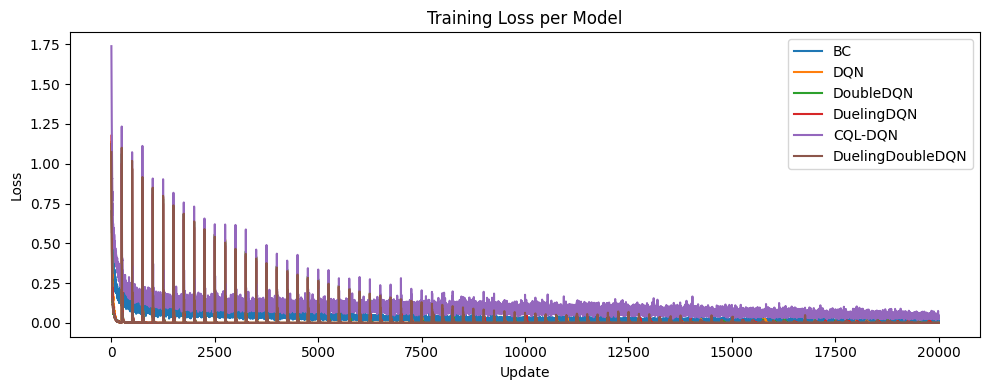

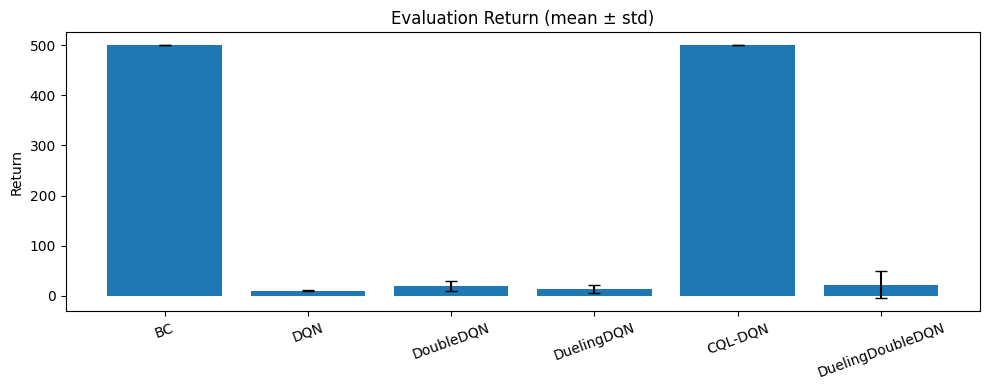

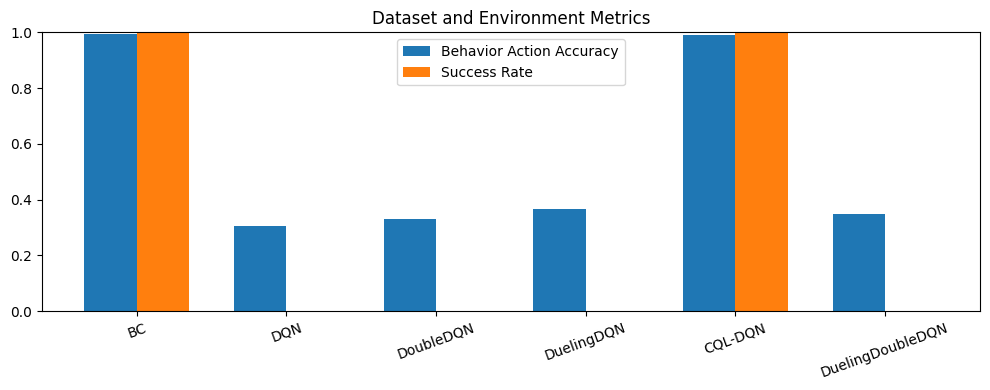

In [11]:
model_names = list(models.keys())
ret_means = [metrics[k]["return_mean"] for k in model_names]
ret_stds = [metrics[k]["return_std"] for k in model_names]
acc_vals = [metrics[k]["behavior_action_acc"] for k in model_names]
succ_vals = [metrics[k]["success_rate"] for k in model_names]

plt.figure(figsize=(10, 4))
for name in model_names:
    plt.plot(loss_history[name], label=name)
plt.title("Training Loss per Model")
plt.xlabel("Update")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(model_names, ret_means, yerr=ret_stds, capsize=4)
plt.title("Evaluation Return (mean ± std)")
plt.ylabel("Return")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
x = np.arange(len(model_names))
w = 0.35
plt.bar(x - w / 2, acc_vals, width=w, label="Behavior Action Accuracy")
plt.bar(x + w / 2, succ_vals, width=w, label="Success Rate")
plt.xticks(x, model_names, rotation=20)
plt.ylim(0.0, 1.0)
plt.title("Dataset and Environment Metrics")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

results_df = pd.DataFrame.from_dict(metrics, orient="index")
results_df = results_df[[
    "return_mean",
    "return_std",
    "length_mean",
    "length_std",
    "success_rate",
    "behavior_action_acc",
]].sort_values("return_mean", ascending=False)

display(results_df.style.format({
    "return_mean": "{:.2f}",
    "return_std": "{:.2f}",
    "length_mean": "{:.1f}",
    "length_std": "{:.1f}",
    "success_rate": "{:.2%}",
    "behavior_action_acc": "{:.2%}",
}))

,return_mean,return_std,length_mean,length_std,success_rate,behavior_action_acc
BC,500.00,0.00,500.0,0.0,100.00%,99.33%
CQL-DQN,500.00,0.00,500.0,0.0,100.00%,99.06%
DuelingDoubleDQN,22.20,27.30,22.2,27.3,0.00%,34.67%
DoubleDQN,20.10,9.49,20.1,9.5,0.00%,33.08%
DuelingDQN,13.95,8.63,13.9,8.6,0.00%,36.72%
DQN,10.40,1.66,10.4,1.7,0.00%,30.35%
